## Non-Majors Survey Results

Jismi Mathew

10/15/2025

Purpose: Perform Data Analysis on Non-Majors Survey Results to document the findings that can help guide the recruiting or messaging efforts of the CCM IT Department.

In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
datafile = 'nonmajors_survey_cleaned_survey_data.csv'
df = pd.read_csv(datafile, parse_dates=True)

### Question 1: What are the main motivations for non-majors to enroll in a computing class at CCM? 

In [4]:
# Select motivation columns
motivation_cols = [col for col in df.columns if col.startswith('motivation_')]

In [5]:
# Convert to lowercase strings and count only the 'yes' responses
motivation_counts = (
    df[motivation_cols]
      .apply(lambda s: s.astype(str).str.strip().str.lower().eq('yes'))
      .sum()
      .sort_values(ascending=False)
)

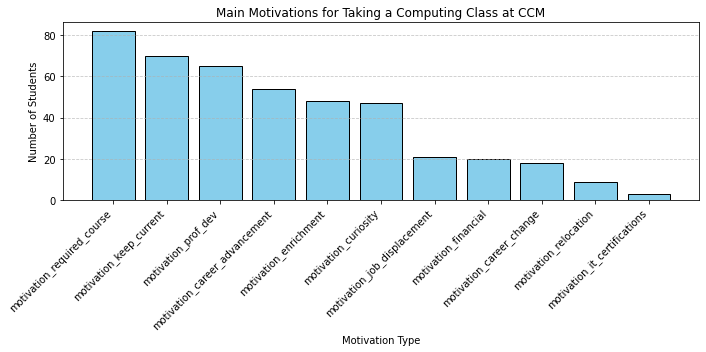

In [6]:
# Plot clean bar chart
plt.figure(figsize=(10, 5))
plt.bar(motivation_counts.index, motivation_counts.values, color='skyblue', edgecolor='black')
plt.title('Main Motivations for Taking a Computing Class at CCM')
plt.xlabel('Motivation Type')
plt.ylabel('Number of Students')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Findings for Q1: 

Some of the main motivations for non CS Major students to take a Computing Class at CCM are because it is a required course, to keep current in computing, for professional development, or career advancement. The least number of students are taking these courses in order to recieve an IT certificate, due to relocation or career change. 

### Question 2: Does prior exposure to CCM events or IT activities increase the likelihood of students wanting to take more computing classes?

In [7]:
#Select event columns
event_cols = [col for col in df.columns if col.startswith('event_')]

In [8]:
# Convert "Yes"/"No" into numeric values (1/0)
events_yes = df[event_cols].apply(lambda s: s.astype(str).str.strip().str.lower().eq('yes'))
df['num_events'] = events_yes.sum(axis=1)

In [9]:
# Group by participation level
bins = [-1, 0, 1, 10]
labels = ['None', 'Some', 'Many']
df['event_group'] = pd.cut(df['num_events'], bins=bins, labels=labels)

In [10]:
# Convert interest to numeric
interest_col = 'on_a_scale_of_1_to_5_with_1_being_not_at_all_interested_and_5_being_extremely_interested_how_interested_are_you_taking_more_courses_in_computer_science_information_technology_or_game_development'
df['interest_level'] = pd.to_numeric(df[interest_col], errors='coerce')

In [11]:
# 5. Compute mean interest by group
avg_interest = df.groupby('event_group', dropna=True)['interest_level'].mean()

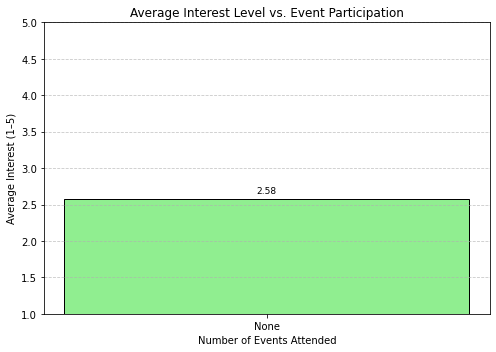

In [12]:
# Plot graph (with value labels)
plt.figure(figsize=(7,5))
plt.bar(avg_interest.index, avg_interest.values, color='lightgreen', edgecolor='black')
plt.title('Average Interest Level vs. Event Participation')
plt.xlabel('Number of Events Attended')
plt.ylabel('Average Interest (1–5)')
plt.ylim(1, 5)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels above bars
for i, v in enumerate(avg_interest.values):
    if pd.notna(v):
        plt.text(i, v + 0.05, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [13]:
# return number for each column
df['event_group'].value_counts(dropna=False)

None    92
Some     0
Many     0
Name: event_group, dtype: int64

#### Findings for Q2:

The chart above shows the average interest level (1–5 scale) by the number of CCM events a student attended.
In this dataset, all respondents reported no prior event participation, so only one bar appears.
The average interest score for these students is around 2.6, showing a moderate level of interest even without prior exposure.

### Question 3: Through which sources do students typically learn about CCM and its computing courses?

In [14]:
# Select 'how did you hear' columns
source_cols = [c for c in df.columns if "how_did_you_hear" in c.lower()]

In [15]:
# Count "yes" responses (case-insensitive)
source_counts = (
    df[source_cols]
      .apply(lambda col: col.astype(str).str.strip().str.lower().eq('yes').sum())
      .sort_values(ascending=True)
)

In [16]:
# Simplify labels for Y-axis
clean_labels = (
    source_counts.index
    .str.replace('how_did_you_hear_about_county_college_of_morris_', '', regex=False)
    .str.replace('ccm_', '', regex=False)
    .str.replace('_', ' ', regex=False)
    .str.title()
)

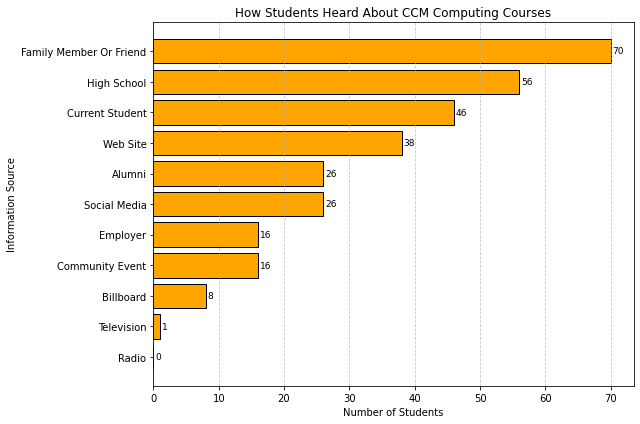

In [17]:
# Plot
plt.figure(figsize=(9,6))
plt.barh(clean_labels, source_counts.values, color='orange', edgecolor='black')
plt.title('How Students Heard About CCM Computing Courses')
plt.xlabel('Number of Students')
plt.ylabel('Information Source')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add count labels
for y, v in enumerate(source_counts.values):
    plt.text(v + 0.3, y, str(int(v)), va='center', fontsize=9)

plt.tight_layout()
plt.show()

#### Findings for Q4:

Most students reported hearing about CCM through family or friends, followed by high school connections and current students. Other sources, such as the CCM website, alumni, and social media were also beneficial to getting the word out, but to a lesser extent. Traditional advertising methods like billboards, television and radio were the least common sources. Overall, this suggests that more personal connections and school outreach are the most effective ways for future students to learn about CCM's computing programs. 

### Question 4: Are there demographic groups, such as women, older students, or underrepresented minorities, who are less represented in computing literacy courses at CCM?

In [18]:
# pick all "interest_" columns
interest_cols = [c for c in df.columns if c.startswith('interest_')]

In [19]:
# count 'Yes' answers per course (case/space safe; doesn't modify df)
interest_counts = (
    df[interest_cols]
      .apply(lambda s: s.astype(str).str.strip().str.lower().eq('yes').sum())
      .sort_values(ascending=True)   # ascending for a clean horizontal chart
)

In [20]:
# make labels more readable
clean_labels = (
    interest_counts.index
      .str.replace('interest_', '', regex=False)
      .str.replace('_', ' ', regex=False)
      .str.title()
)

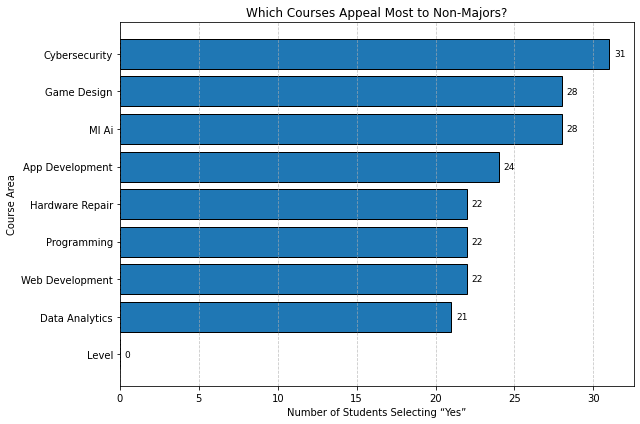

In [21]:
# Plot
plt.figure(figsize=(9,6))
plt.barh(clean_labels, interest_counts.values, edgecolor='black')
plt.title('Which Courses Appeal Most to Non-Majors?')
plt.xlabel('Number of Students Selecting “Yes”')
plt.ylabel('Course Area')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# annotate counts on bars
for y, v in enumerate(interest_counts.values):
    plt.text(v + 0.3, y, str(int(v)), va='center', fontsize=9)

plt.tight_layout()
plt.show()

#### Findings for Q4:

Cybersecurity, game design, and ML/AI seem to attract the most interest amoung non-major stusdents. Courses like App Development, Programming, Web Development and Hardware Repair also show solid interest.

### Citations:

chatgpt.com